In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

In [3]:
import sys

import matplotlib

sys.path.append("..")

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

## A simulation of intra-v-extracellular signal:



In [4]:
from sympy import integrate, lambdify, pi, simplify, symbols

# slice-height/2, helper-height, z, cell radius
h, k, z, r, m, um = symbols("h k z r m μm")

vol_sphere = 4 / 3 * pi * r**3
vol_cap = (pi * k**2) / 3 * (3 * r - k)  # from 0 to 2*r

area_base_cap = pi * (r**2 - (r - k) ** 2)  # from 0 to 2*r

# segment centered at 0,from -h to h
vol_segment = simplify(integrate(area_base_cap, (k, z + r - h, z + r + h)))

vol_fp_sphere = 2 * h * pi * r**2
vol_fp_cap = area_base_cap * h * 2

# case r<h;  z=vertical position of center of ball:

# ball entirely in slice, from z=0 to z=h-r:
cell_in_slice = integrate(vol_sphere, (z, 0, h - r))

# ball moving out of slice:
cell_moving_out = integrate(vol_cap, (k, 0, r * 2))

# the largest diameter of the sphere is inside the slice, from z=0 to z=h:
cell_max_in_slice_fp = integrate(vol_fp_sphere, (z, 0, h))

# the cell is moving out of the slice:
cell_moving_out_fp = integrate(vol_fp_cap, (k, 0, r * 2))

cell_signal = simplify(cell_in_slice + cell_moving_out)
fp_signal = simplify(cell_max_in_slice_fp + cell_moving_out_fp)
purity_r_below_h = (cell_signal / fp_signal) * 2


# case r>h;  z=vertical position of center of ball:

cell_cut_top_bottom = integrate(vol_segment, (z, 0, r - h))
cell_cut_top = integrate(vol_cap, (k, 0, 2 * h))

purity_r_above_h = simplify(cell_cut_top_bottom + cell_cut_top) / fp_signal * 2

purity_r_below_h

4.0*r/(3*h + 4*r)

In [5]:
def simulate_purity(ds, hs):
    observation_list = []
    observation_list_full_signal = []

    for h in hs:
        observation_list.append([])
        observation_list_full_signal.append([])

        for d in ds:
            r = d // 2

            X, Y, Z = np.meshgrid(
                np.linspace(-r, r, 2 * r + 1),
                np.linspace(-r, r, 2 * r + 1),
                np.linspace(0, h, h),
            )

            observations = []
            observations_full_signal = []

            for i, d in enumerate(range(-r - h - 1, r + 2, 1)):
                sphere = (X**2 + Y**2 + (Z + d) ** 2) ** 0.5 <= r

                if sphere.sum() > 0:
                    signal = sphere[sphere.sum(-1) > 0]

                    den = signal.sum(-1) / h

                    observations += list(den)
                    observations_full_signal += list(signal.mean(-1) == 1)

            observation_list[-1].append(np.mean(observations))
            observation_list_full_signal[-1].append(np.mean(observations_full_signal))

    return np.array(observation_list), np.array(observation_list_full_signal)

In [6]:
# Modeling contaminated vs. pure signal ratio;

# slice-height/2, helper-height, z, cell radius
h, k, z, r, m, d, um = symbols("h k z r m d μm")

vol_sphere = 4 / 3 * pi * r**3
vol_cap = (pi * k**2) / 3 * (3 * r - k)  # from 0 to 2*r

area_base_cap = pi * (r**2 - (r - k) ** 2)  # from 0 to 2*r

# segment centered at 0,from -h to h
vol_segment = simplify(integrate(area_base_cap, (k, z + r - h, z + r + h)))

vol_fp_sphere = 2 * h * pi * r**2
vol_fp_cap = area_base_cap * h * 2

# calculate overall footprint:
cell_max_in_slice_fp = vol_fp_sphere
# the cell is moving out of the slice:
cell_moving_out_fp = integrate(area_base_cap, (k, 0, r * 2))

# # cell_signal = simplify(cell_in_slice+cell_moving_out)
fp_signal = simplify(cell_max_in_slice_fp + cell_moving_out_fp)

# case r>h;  z=vertical position of center of ball:

fp_clean_signal = integrate(area_base_cap, (k, 0, r - h)) * 2
clean_signal_ratio = simplify(fp_clean_signal / (fp_signal))

clean_signal_ratio

(h - r)**2*(h + 2*r)/(r**2*(3*h + 2*r))

In [7]:
clean_signal_ratio_d = simplify(clean_signal_ratio.subs(r, d))
purity_r_below_h_d = simplify(purity_r_below_h.subs(r, d / 2))

clean_signal_ratio_d

(d - h)**2*(2*d + h)/(d**2*(2*d + 3*h))

In [8]:
hs = np.arange(1, 27)
ds = np.arange(1, 27, 1)

observations, observations_full_signal = simulate_purity(ds, hs)

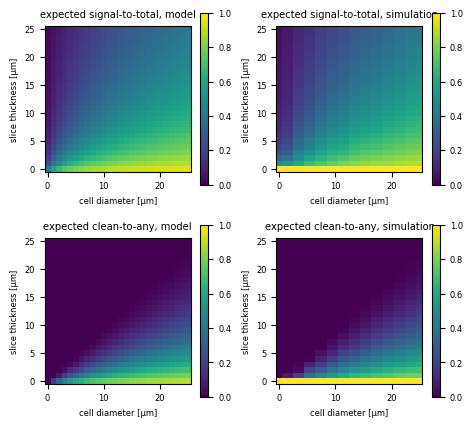

In [9]:
D, H = np.meshgrid(ds, hs)

purity_np = lambdify((d, h), purity_r_below_h_d, modules="numpy")
clean_signal_ratio_np = lambdify((d, h), clean_signal_ratio_d, modules="numpy")


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12 * CM, 11 * CM))

ax = axs[0, 0]

ax.set_title("expected signal-to-total, model")
im = ax.imshow((purity_np(D, H)), cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax)


ax = axs[0, 1]
ax.set_title("expected signal-to-total, simulation")
im = ax.imshow(observations, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

ax = axs[1, 0]
ax.set_title("expected clean-to-any, model")
im = ax.imshow(clean_signal_ratio_np(D, H) * (D > H), cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

ax = axs[1, 1]
ax.set_title("expected clean-to-any, simulation")
im = ax.imshow(observations_full_signal, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax)

for ax in axs.ravel():
    ax.set(xlabel="cell diameter [μm]", ylabel="slice thickness [µm]")
    ax.invert_yaxis()

fig.tight_layout()
fig.savefig("signal_strength_simulation.svg", **save_kwargs)

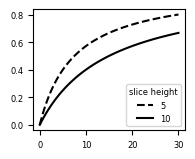

In [10]:
x = np.linspace(0, 30, 100)

fig, ax = plt.subplots(figsize=(5 * CM, 4 * CM))

ax.plot(x, purity_np(x, 5), "k--", label="5")
ax.plot(x, purity_np(x, 10), "k", label="10")
ax.legend(title="slice height")

fig.savefig("signal_purity_lines.svg", **save_kwargs)

<lambdifygenerated-2>:2: RuntimeWarning: divide by zero encountered in divide
  return (d - h)**2*(2*d + h)/(d**2*(2*d + 3*h))


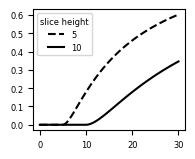

In [11]:
fig, ax = plt.subplots(figsize=(5 * CM, 4 * CM))

y = clean_signal_ratio_np(x, 5)
y[x < 5] = 0
ax.plot(x, y, "k--", label="5")

y = clean_signal_ratio_np(x, 10)
y[x < 10] = 0
ax.plot(x, y, "k", label="10")
ax.legend(title="slice height")

fig.savefig("signal_clean_lines.svg", **save_kwargs)

In [12]:
def quiver_vf(vf, scale=5):
    vf_norm = vf.sum(-1) + 0.01
    vf /= vf_norm[:, :, None]

    angles = np.linspace(0, 2 * np.pi, 3, endpoint=False)
    x_ends = np.cos(angles)
    y_ends = np.sin(angles)

    u = (vf * x_ends[None, None]).mean(-1)
    v = (vf * y_ends[None, None]).mean(-1)

    uv_norm = np.sqrt(u**2 + v**2)
    u /= uv_norm
    v /= uv_norm

    fig, ax = plt.subplots(figsize=(11, 8))

    ax.set_facecolor([0.95, 0.95, 0.95])
    ax.scatter(
        *np.meshgrid(np.arange(vf.shape[1]), np.arange(vf.shape[0])), c="k", s=100
    )
    ax.quiver(
        *np.meshgrid(np.arange(vf.shape[1]), np.arange(vf.shape[0])),
        u * vf_norm,
        v * vf_norm,
        np.arctan2(v, u),
        angles="uv",
        scale=scale,
        cmap=cmap,
        width=0.012,
        headwidth=4,
    )

    ax.set(xticks=[], yticks=[], xlim=(-0.5, 10.5), aspect="equal")
    return fig

In [13]:
### create a 3d figurette to display the algorithm:
cmap = LinearSegmentedColormap.from_list("cmap", ["red", "orange", "lime"])

# fmt: off
green_cells_top = [[1, 4], [4, 6], [3, 2], [3, 4], [2, 6], [3, 5], [1, 2], [4, 8], [6,2], [5,3], [6,9]]
orange_cells_top = [[3, 0], [5, 0], [4, 1]]
red_cells_top = [[1, 9], [6, 6]]

green_cells_bottom = [[1, 4], [3, 2], [3, 5], [1, 2], [5, 7], [6, 3], [5, 3]]
orange_cells_bottom = [[5, 0], [2, 6], [3, 5], [3, 4]]
red_cells_bottom = [[2, 9], [3, 1]]
# fmt: on

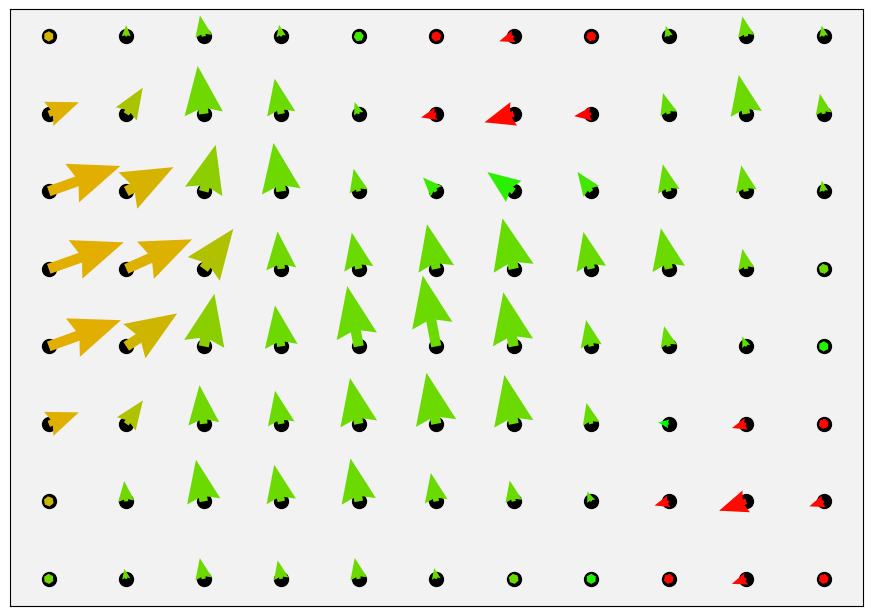

In [14]:
vf_top = np.zeros((8, 11, 3))
for i, cell_idcs in enumerate([orange_cells_top, green_cells_top, red_cells_top]):
    vf_top[[c[0] for c in cell_idcs], [c[1] for c in cell_idcs], i] = 1

vf_top = gaussian_filter(vf_top, 0.8)
vf_top[..., -1] /= 2

fig = quiver_vf(vf_top)
fig.savefig("vf_top.svg", **save_kwargs)

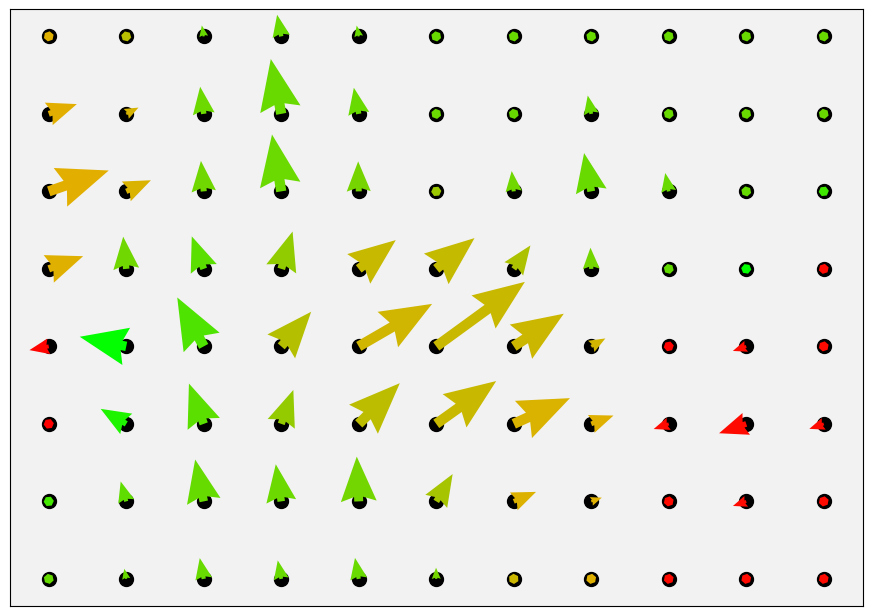

In [15]:
vf_bottom = np.zeros((8, 11, 3))
for i, cell_idcs in enumerate(
    [orange_cells_bottom, green_cells_bottom, red_cells_bottom]
):
    vf_bottom[[c[0] for c in cell_idcs], [c[1] for c in cell_idcs], i] = 1

vf_bottom = gaussian_filter(vf_bottom, 0.8)
vf_bottom[..., -1] /= 2

fig = quiver_vf(vf_bottom)
fig.savefig("vf_bottom.svg", **save_kwargs)

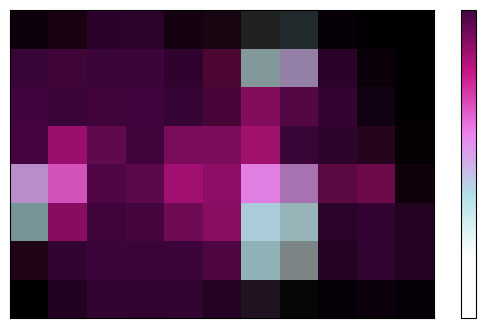

In [16]:
cmap = LinearSegmentedColormap.from_list(
    "rolands_pride",
    ["#430541", "mediumvioletred", "violet", "powderblue", "white", "white"][::-1],
)

cosine_similarity_top_bottom = (
    (vf_top / np.sqrt((vf_top**2).sum(-1))[:, :, None])
    * (vf_bottom / np.sqrt((vf_bottom**2).sum(-1))[:, :, None])
).sum(-1)
cosine_similarity_top_bottom[:, :6] **= 0.3
cosine_similarity_top_bottom[:, 8:] **= 0.3

signal = vf_top.sum(-1) + vf_bottom.sum(-1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor("k")
im = ax.imshow(
    cosine_similarity_top_bottom, cmap=cmap, alpha=(signal / signal.max()) ** 4
)
ax.invert_yaxis()

ax.set(xticks=[], yticks=[])

cbar = fig.colorbar(im)
cbar.set_ticks([])